## Loading the data and pre-processing

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

PINN_result_dir = "/data/Sunav/Final_Deep_Ens_grid_search/LS_DE_scaled"             # Change this to correct directory as required
exp_data_dir = "/data/Sunav/Code_Diffusion_PINN/data/"                              # Change this to correct directory as required

u_hat_mean = np.load(os.path.join(PINN_result_dir,"best/u_hat_mean_750.npy"))       # Change this as required         
u_hat_std  = np.load(os.path.join(PINN_result_dir,"best/u_hat_std_750.npy"))        # Change this as required  

d_hat_mean = np.load(os.path.join(PINN_result_dir,"best/d_hat_mean_750.npy"))       # Change this as required         
d_hat_std  = np.load(os.path.join(PINN_result_dir,"best/d_hat_std_750.npy"))        # Change this as required 

# Build ensemble arrays (750, Nt, Nx)
u_hat_ens = np.load(os.path.join(PINN_result_dir, "LS_u_hat_ens.npy"))
d_hat_ens = np.load(os.path.join(PINN_result_dir, "LS_d_hat_ens_scaled.npy"))

# -------------------------------------------------------------------- #
# 1) LOAD EXPERIMENTAL DATA & TIME
# -------------------------------------------------------------------- #

data_all = np.load(os.path.join(exp_data_dir, "LS_log_profiles.npy"))
scaling_factor = -5.44366                       # gm/cm^3    ## X-ray quantification attenuation scaling coefficient
data_all = scaling_factor * data_all  * 0.805   # scaling for matching with gravimetric data at stabilized lower boundary value

t_data_all = np.load(os.path.join(exp_data_dir, "LS_difference_times.npy"))
t_data_all = t_data_all                         # shape => (N_time_exp,)
t_max = np.max(t_data_all)
N_time_exp = len(t_data_all)

train_idx = [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 19, 20, 22, 23, 25]
test_idx  = [i for i in range(len(t_data_all)) if i not in train_idx]

train_times = t_data_all[train_idx]
test_times  = t_data_all[test_idx]


# Pixel size in micrometers:
pixel_size = 31.63  # micrometers
# Convert to cm by dividing by 1000
# => each pixel ~ 0.03163 mm, or 3.163e-3 cm    # this is only for this experiment, change according to 
x_data_exp_cm = np.arange(data_all.shape[1]) * pixel_size / 10000.0

# Length of ROI/specimen
L = np.max(x_data_exp_cm) # cm
print("Sample/ROI Length:", L, "cm")

# This scaling factor, converts the PINN diffusion prediction to physical units - note PINN inputs are normalized x and t, so a conversion is required. 
diffusion_scaling_factor = np.max(L)**2/(4*np.max(t_data_all))
print("Diffusion scaling factor:", diffusion_scaling_factor)


Sample/ROI Length: 2.463977 cm
Diffusion scaling factor: 0.00838561140404558


# Using Latin Hypercube Sampling- Lets determine the idea/optimal degree of polynomial fit

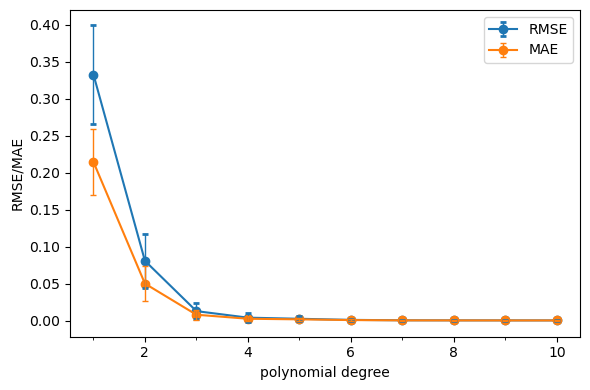

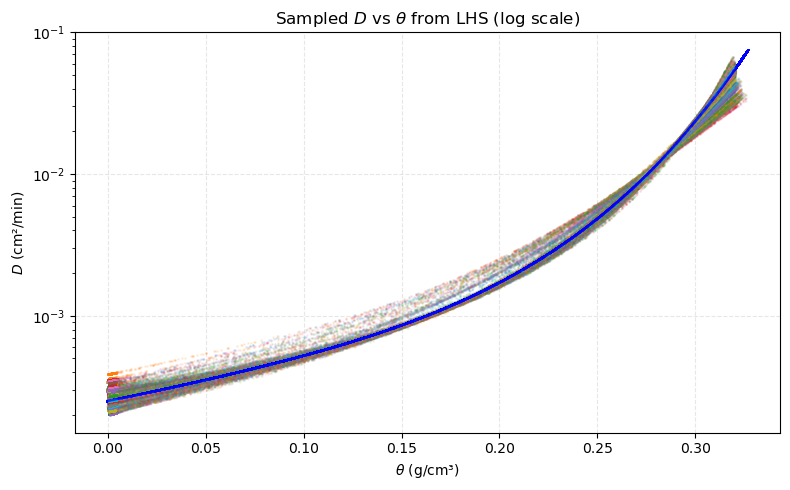

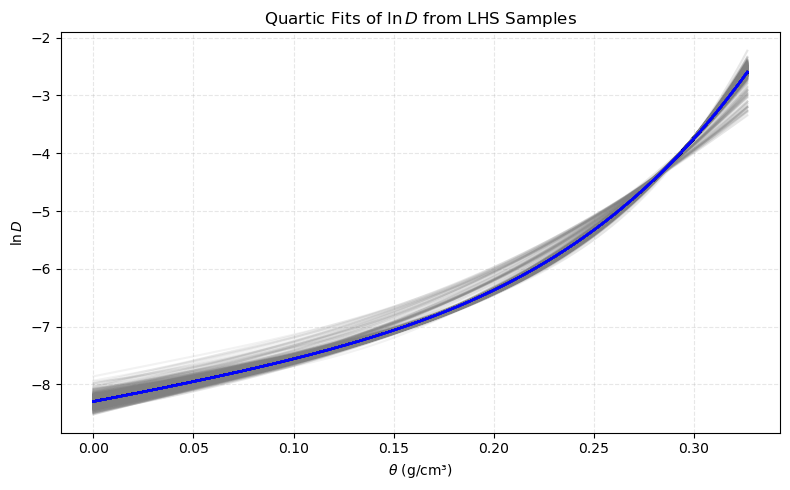

Mean Quartic Coefficients for ln(D) vs. θ from average of 750 fits evaluated on fixed grid:
coefficient form is: ln(D) = a·θ⁴ + b·θ³ + c·θ² + d·θ + e
Coefficient a = 319.377527
Coefficient b = -28.106100
Coefficient c = 8.616007
Coefficient d = 6.462060
Coefficient e = -8.293850


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from numpy.polynomial import Polynomial

#  u_hat_ens and d_hat_ens are already defined
n_ensembles, Nt, Nx = u_hat_ens.shape
n_samples = 1000
eps = 1e-12  # To avoid log(0)

# Preallocate arrays
u_hat_LHS = np.zeros((n_ensembles, n_samples))
d_hat_LHS = np.zeros((n_ensembles, n_samples))
coeff_matrix = np.zeros((n_ensembles, 5))

# Latin Hypercube sampler for 2D grid indices
sampler = qmc.LatinHypercube(d=1, seed=42)

for i in range(n_ensembles):
    theta_flat = u_hat_ens[i].ravel()
    D_flat = d_hat_ens[i].ravel()

    # LHS indices
    sample = sampler.random(n=n_samples)
    indices = (sample * len(theta_flat)).astype(int).flatten()

    u_hat_LHS[i] = theta_flat[indices]
    d_hat_LHS[i] = D_flat[indices]


# ------------------------------------------------------------------
# 1) helper – fit degree-k poly in *real θ* power basis
# ------------------------------------------------------------------
def compute_poly_fits_and_errors(θ_ens, D_ens, deg, eps=1e-15):
    nE, nS = θ_ens.shape
    coeff = np.zeros((nE, deg + 1))
    rmse, mae = [], []

    for i in range(nE):
        θ   = θ_ens[i]
        lnD = np.log(np.clip(D_ens[i], eps, None))

        p_u  = Polynomial.fit(θ, lnD, deg=deg)                # scaled fit
        p_θ  = p_u.convert(domain=p_u.domain, window=p_u.domain)
        cdes = p_θ.coef[::-1]                                 # descending
        coeff[i] = cdes

        lnD_pred = np.polyval(cdes, θ)
        res = lnD - lnD_pred
        rmse.append(np.sqrt(np.mean(res**2)))
        mae .append(np.mean(np.abs(res)))

    return coeff, np.asarray(rmse), np.asarray(mae)


# ------------------------------------------------------------------
# 2) Degrees 1-10 fitting RMSE and MSE - optimal complexity of fit
# ------------------------------------------------------------------
degrees   = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
rmse_dict = {}
mae_dict  = {}
mean_rmse = []
mean_mae  = []
rmse_err  = []      
mae_err   = []

for k in degrees:
    _, rmse_k, mae_k = compute_poly_fits_and_errors(u_hat_LHS, d_hat_LHS, deg=k)
    rmse_dict[k], mae_dict[k] = rmse_k, mae_k
    mean_rmse.append(np.nanmean(rmse_k))
    mean_mae .append(np.nanmean(mae_k))
    rmse_err.append(2 * np.nanstd(rmse_k))
    mae_err .append(2 * np.nanstd(mae_k))



fig_e, ax1 = plt.subplots(1, 1, figsize=(6,4))

ax1.errorbar(degrees, mean_rmse, yerr=rmse_err, marker='o',
             capsize=2, capthick = 2, elinewidth=1, barsabove=True, label = 'RMSE')
ax1.errorbar(degrees, mean_mae, yerr=mae_err, marker='o',
             capsize=2, capthick = 1, elinewidth=1, barsabove=True, label = 'MAE')
ax1.xaxis.set_minor_locator(AutoMinorLocator(2)) 
ax1.set(xlabel='polynomial degree', ylabel='RMSE/MAE')

np.save("mean_rmse_HS.npy", mean_rmse)
np.save("rmse_err_HS.npy", rmse_err)
np.save("mean_mae_HS.npy", mean_mae)
np.save("mae_err_HS.npy", mae_err)

#ax1.grid(ls='--', alpha=.3)
plt.legend()
fig_e.tight_layout()
plt.show()


# ------------------------------------------------------------------
# 4) Determine D(θ) by fitting D vs. θ on Lati-hypercube sampled
# ------------------------------------------------------------------

# Assuming u_hat_ens and d_hat_ens are already defined
n_ensembles, Nt, Nx = u_hat_ens.shape
n_samples = 1000
eps = 1e-12  # To avoid log(0)

# Preallocate arrays
u_hat_LHS = np.zeros((n_ensembles, n_samples))
d_hat_LHS = np.zeros((n_ensembles, n_samples))
coeff_matrix = np.zeros((n_ensembles, 5))

# Latin Hypercube sampler for 2D grid indices
sampler = qmc.LatinHypercube(d=1, seed=42)


### METHOD - BLUE - 
# 1. DO LHS for EACH ENSEMBLE, 
# 2.  FIT POLYNOMIAL TO ln_D_LHS vs u__hat_LHS,
# 3. EVALUATE 750 FITTED ON FIXED GRID, 
# 4. AVERAGE 750 fits for each grid point, 
# 5. Do a final fit on the average of 750 fixed grid polynomial evaluations


for i in range(n_ensembles):
    theta_flat = u_hat_ens[i].ravel()
    D_flat = d_hat_ens[i].ravel()

    # LHS indices
    sample = sampler.random(n=n_samples)
    indices = (sample * len(theta_flat)).astype(int).flatten()

    u_hat_LHS[i] = theta_flat[indices]
    d_hat_LHS[i] = D_flat[indices]


# Polynomial fit: 
    lnD = np.log(np.clip(d_hat_LHS[i], a_min=eps, a_max=None))
    try:
        p = Polynomial.fit(u_hat_LHS[i], lnD, deg=4)
        coeff_std_basis = p.convert().coef[::-1]
        coeff_matrix[i, :] = coeff_std_basis
    except Exception:
        coeff_matrix[i, :] = np.nan


# Evaluate the fitted polynomial curves
theta_grid = np.linspace(0, np.max(u_hat_ens), 1000)
lnD_fits = np.zeros((n_ensembles, len(theta_grid)))


# Evaluate the fits on a fixed grid for all ensembles
for i in range(n_ensembles):
    coeffs = coeff_matrix[i]
    p = Polynomial(coeffs[::-1])        # coeff_matrix stores descending [a4..a0]; Polynomial() needs ascending, so reverse back
    lnD_fits[i] = p(theta_grid)


# Mean ln_D of lnD_fits from subsampled D vs theta evaluated on the fixed theta grids.
lnD_mean = lnD_fits.mean(axis=0)    # Takes the mean of 750 fitted equations


# Plot D vs theta (log Y scale)
plt.figure(figsize=(8, 5))
for i in range(n_ensembles):
    plt.plot(u_hat_LHS[i], d_hat_LHS[i], 'o', markersize=1, alpha=0.1)
    plt.plot(theta_grid, np.exp(lnD_mean), color='blue', label='Mean ln D Evaluated LHS Fits', alpha=0.7)
plt.yscale('log')
plt.xlabel(r'$\theta$ (g/cm³)')
plt.ylabel(r'$D$ (cm²/min)')
plt.title('Sampled $D$ vs $\\theta$ from LHS (log scale)')
plt.grid(ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Plot fitted quartic curves
plt.figure(figsize=(8, 5))
for i in range(n_ensembles):
    plt.plot(theta_grid, lnD_fits[i], color='gray', alpha=0.1)
    plt.plot(theta_grid, lnD_mean, color='blue', label='Mean ln D Evaluated LHS Fits', alpha=0.7)
plt.xlabel(r'$\theta$ (g/cm³)')
plt.ylabel(r'$\ln D$')
plt.title('Quartic Fits of $\ln D$ from LHS Samples')
plt.grid(ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Find the coefficient of mean quartic fit lnD_mean vs theta_grid
p_mean = Polynomial.fit(theta_grid, lnD_mean, deg=4)
coeff_mean = p_mean.convert().coef[::-1]  # Coefficients in descending order

# Print the coefficients for the fit on average of 750 fits evaluates on the fixed grid

coeff_names = ["a", "b", "c", "d", "e"]

print("Mean Quartic Coefficients for ln(D) vs. θ from average of 750 fits evaluated on fixed grid:")
print("coefficient form is: ln(D) = a·θ⁴ + b·θ³ + c·θ² + d·θ + e")
for i, coeff in enumerate(coeff_mean):
    print(f"Coefficient {coeff_names[i]} = {coeff:.6f}")  # a_4, a_3, a_2, a_1, a_0

 
